In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
import koreanize_matplotlib

from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize, proportion_confint
from statsmodels.stats.power import NormalIndPower
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu

from sklearn.metrics import roc_curve, precision_recall_curve

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

In [2]:
df = pd.read_csv('course_final.csv')

### 1. Registered에서 Viewed로 넘어가지 못 한 유저

registered 유저 중 14일 이상의 로그 기록을 보인 비율은 9%

단순히 duration이 1인 로그가 대략 80% 정도로 보임

14일 이후에 로그가 찍힌 유저 수의 비율 :  0.09390697496069635
registered 유저 수 :  208632


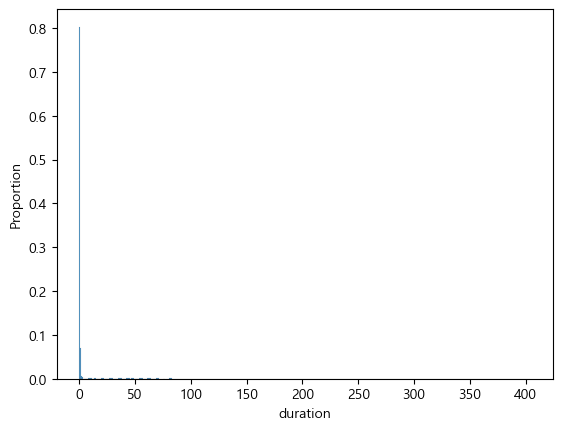

In [7]:
df_registered = df[df['viewed'] == 0]
sns.histplot(df_registered['duration'], stat = 'proportion')

df_tmp = df_registered['duration'].value_counts().reset_index().sort_values('duration')
print('14일 이후에 로그가 찍힌 유저 수의 비율 : ', df_tmp.loc[df_tmp['duration'] > 14,'count'].sum() / len(df_registered))
print('registered 유저 수 : ', len(df_registered))

우선 Registered의 의미 자체가 Viewed로 넘어가지 못 한 그룹이기에 초기 이탈 그룹으로 보는 것이 적절하다.

### 2. Viewed에서 수강 변경 기간(14일) 이내에 이탈한 그룹

Viewed로 넘어갔지만 이 그룹도 특정 기간의 수강 변경 및 포기를 할 수 있는 2주간의 기간이 존재함.

따라서, Registered -> Viewed와 함께, 14일을 이탈의 초기 구간으로 설정해서 EDA를 진행함

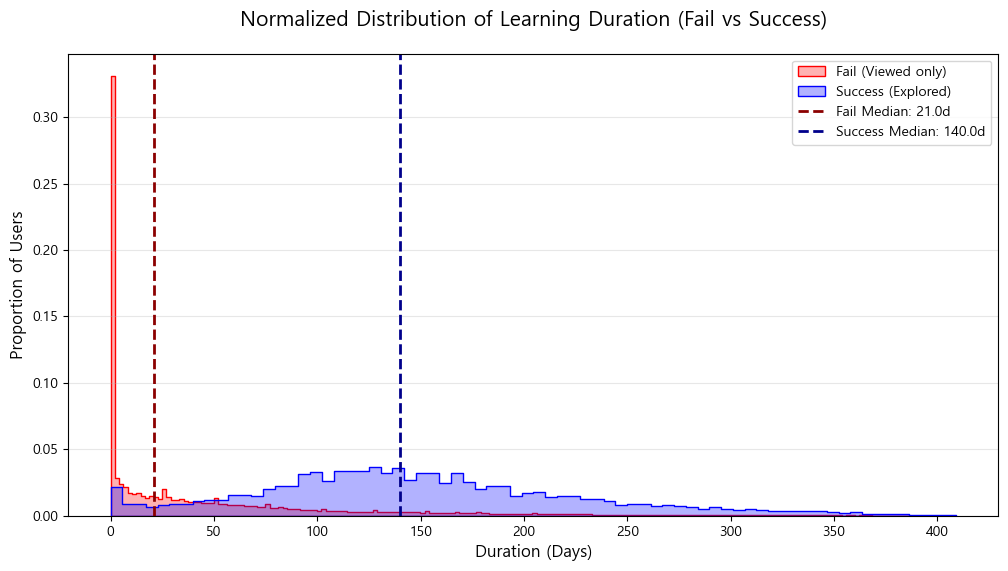

In [8]:
df_viewed = df[df['viewed'] == 1]

df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

median_fail = df_fail_explored['duration'].median()
median_suc = df_suc_explored['duration'].median()

plt.figure(figsize=(12, 6))

# 성공/실패 그룹의 비율(Proportion) 비교
# common_norm=False를 해야 각 그룹별로 100% 기준이 잡힙니다.
sns.histplot(data=df_fail_explored, x='duration', color='red', label='Fail (Viewed only)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

sns.histplot(data=df_suc_explored, x='duration', color='blue', label='Success (Explored)', 
            stat='proportion', common_norm=False, alpha=0.3, element="step")

# 중앙값 표시
plt.axvline(median_fail, color='darkred', linestyle='--', linewidth=2, label=f'Fail Median: {median_fail}d')
plt.axvline(median_suc, color='darkblue', linestyle='--', linewidth=2, label=f'Success Median: {median_suc}d')

# 그래프 디테일
plt.title('Normalized Distribution of Learning Duration (Fail vs Success)', fontsize=15, pad=20)
plt.xlabel('Duration (Days)', fontsize=12)
plt.ylabel('Proportion of Users', fontsize=12) # Y축이 이제 비율(0~1)로 바뀝니다.
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

Viewed의 경우, 30% 이상이 초기에 이탈하는 것을 확인할 수 있음

- 단순히 그림만 보더라도, 통계 검정까지 갈 필요 없이 전체 수강일이 길 수록 강의를 열심히 수강하는 그룹이 늘어남

In [11]:
# viewed 그룹에서 어디에서 많이 이탈하는가
df_proportion = df_fail_explored.value_counts('duration').reset_index().sort_values('duration')
df_proportion['proportion'] = df_proportion['count'] / len(df_fail_explored)
df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()
df_proportion

df_proportion['duration'] = df_proportion['duration'] + 1
start_point = pd.DataFrame({'duration':[0], 'fail_rate':[1.0]})
df_plot = pd.concat([start_point, df_proportion]).sort_values('duration').reset_index(drop = True)
df_plot.head(17)

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,1,0.763174,68153.0,0.236826
2,2,0.690528,20906.0,0.072647
3,3,0.668886,6228.0,0.021642
4,4,0.653377,4463.0,0.015509
5,5,0.640190,3795.0,0.013187
6,6,0.628233,3441.0,0.011957
7,7,0.616307,3432.0,0.011926
8,8,0.604541,3386.0,0.011766
9,9,0.594332,2938.0,0.010209


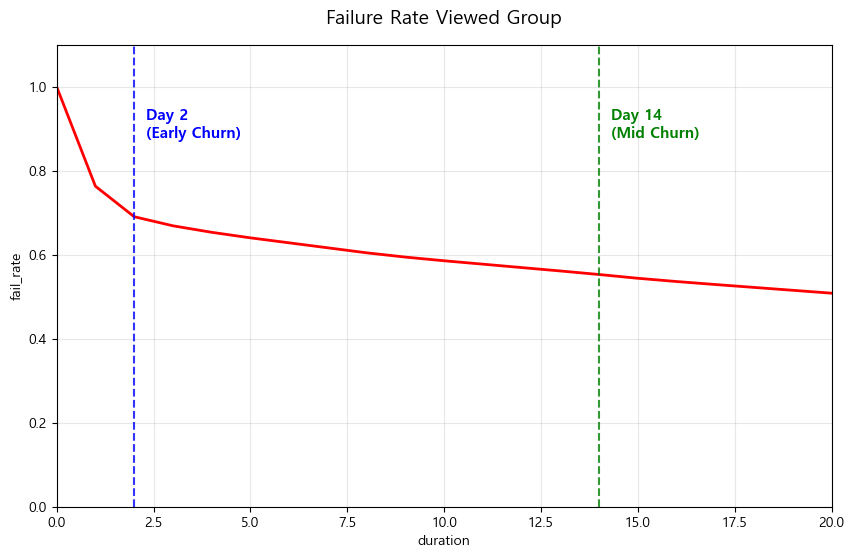

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.axvline(x=2, color='blue', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axvline(x=14, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

plt.text(2.3, 0.95, 'Day 2\n(Early Churn)', color='blue', fontsize=11, fontweight='bold', va='top')
plt.text(14.3, 0.95, 'Day 14\n(Mid Churn)', color='green', fontsize=11, fontweight='bold', va='top')

plt.xlim(0, 20)
plt.ylim(0, 1.1) 
plt.title('Failure Rate Viewed Group', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

현재 도메인 지식과, 데이터를 확인했을 때 초기값을 정할 수 있는 기준은 2가지 정도로 보임.

1. 2일(Viewed 유저의 31% 이탈)

2. 14일(Viewed 유저의 45% 이탈, 수강 변경 및 취소 가능 기간)

nevents        0.018964
ndays_act      0.018964
nplay_video    0.567160
nchapters      0.144112
dtype: float64

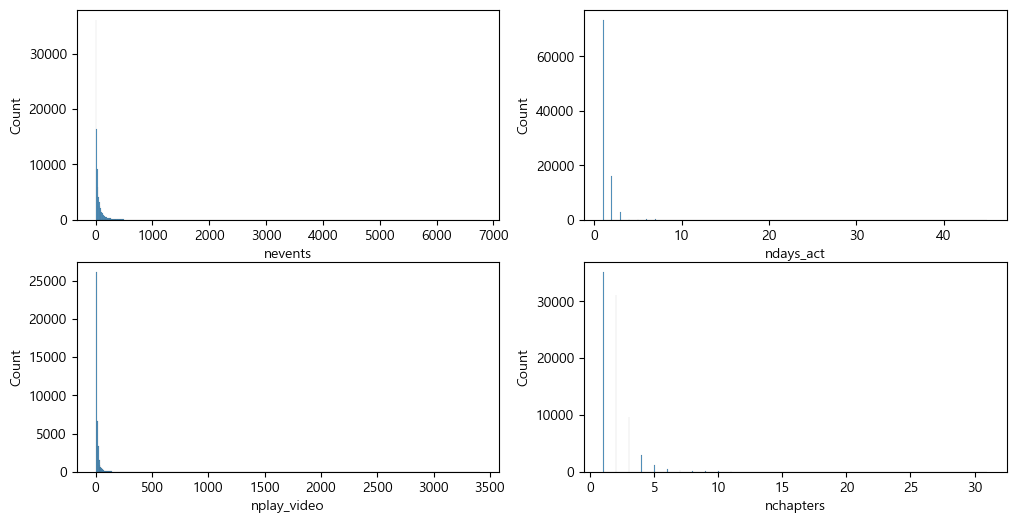

In [15]:
# df_2day만 추출
df_2day = df_fail_explored[df_fail_explored['duration'] <= 2]

fig, axs = plt.subplots(2,2 ,figsize = (12,6))

# nevents, ndays_act, nplay_video, nchapters 4가지에 대한 행동 패턴 시각화
# 생각보다는 행동에 대한 지표들이 어느 정도 보임.

for i, col in enumerate(['nevents','ndays_act','nplay_video','nchapters']):
    sns.histplot(df_2day[col], ax = axs[i // 2][i % 2])

# nplay_video의 결측치 비율로 보았을 때, 초기 이탈은 nplay_video, nchapters로 확인하기는 어렵다.
# 결국 무언가의 행동 패턴을 nevents로 밖에는 판단할 수 없다는 얘기
df_2day[['nevents','ndays_act','nplay_video','nchapters']].isna().sum() / len(df_2day)

(0.0, 200.0)

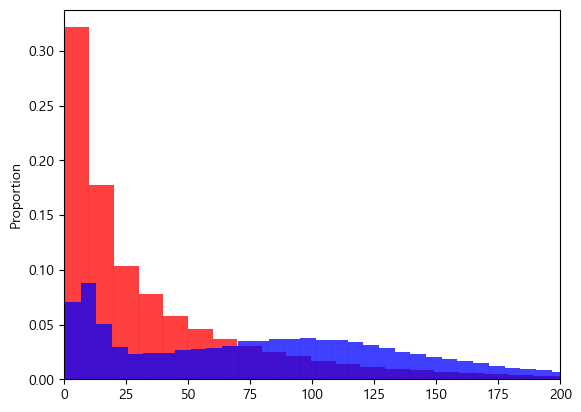

In [ ]:
# 단순 nevents로 cutoff를 제시하게 된다면, 1~3 정도의 낮은 값이 임계값으로 설정될 가능성이 높음
# 따라서, nevents / ndays_act를 통해 explored 그룹이 하루에 몇 번 클릭했는지를 계산하고,
# 특정 quantile을 통해 기준을 제시하는 것이 그나마 가능한 방법일 듯.
df_fail_explored = df_viewed[df_viewed['explored'] == 0]
df_suc_explored = df_viewed[df_viewed['explored'] == 1]

sns.histplot(df_fail_explored['nevents'] / df_fail_explored['ndays_act'], color = 'red', stat = 'proportion')
sns.histplot(df_suc_explored['nevents'] / df_suc_explored['ndays_act'], color = 'blue', stat = 'proportion')

plt.xlim(0,200)

In [18]:
from scipy import stats

# 1. 두 그룹의 변수 정의 (결측치가 있다면 dropna()를 꼭 해주세요)
fail_density = (df_fail_explored['nevents'] / df_fail_explored['ndays_act']).dropna()
suc_density = (df_suc_explored['nevents'] / df_suc_explored['ndays_act']).dropna()

# 2. 맨-휘트니 U 검정 실행 (대립가설: suc_density가 fail_density보다 크다)
stat, p_val = stats.mannwhitneyu(suc_density, fail_density, alternative='greater')

# 3. 각 그룹의 중앙값 확인 (보고서 작성용)
print(f"이탈 그룹(Fail) 일평균 클릭수 중앙값: {fail_density.median():.1f}회")
print(f"수료 그룹(Success) 일평균 클릭수 중앙값: {suc_density.median():.1f}회")
print("-" * 30)
print(f"Mann-Whitney U 통계량: {stat}")
print(f"P-value: {p_val}")

if p_val < 0.05:
    print("결론: 두 그룹 간의 일평균 몰입도(클릭수)는 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론: 통계적으로 유의미한 차이가 없습니다.")

이탈 그룹(Fail) 일평균 클릭수 중앙값: 20.3회
수료 그룹(Success) 일평균 클릭수 중앙값: 83.8회
------------------------------
Mann-Whitney U 통계량: 7936023760.0
P-value: 0.0
결론: 두 그룹 간의 일평균 몰입도(클릭수)는 통계적으로 유의미한 차이가 있습니다.


In [19]:
# stat은 아까 구한 Mann-Whitney U 통계량
n1 = len(suc_density)
n2 = len(fail_density)

# 효과크기 (Rank-Biserial Correlation) 계산
effect_size = 1 - (2 * stat) / (n1 * n2)
print(f"효과크기 (Effect Size): {abs(effect_size):.3f}")

효과크기 (Effect Size): 0.477


Viewed와 Explored 그룹의 일 평균 클릭 수가 차이가 존재.

-> Viewed에서도 2일 이내는 행동 지표가 더 낮을 것이므로, 이 통계 검정 결과의 차이가 그대로 유지가 될 것이기에 일평균 클릭수로 진행

C:\temp\ipykernel_25584\1336442380.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


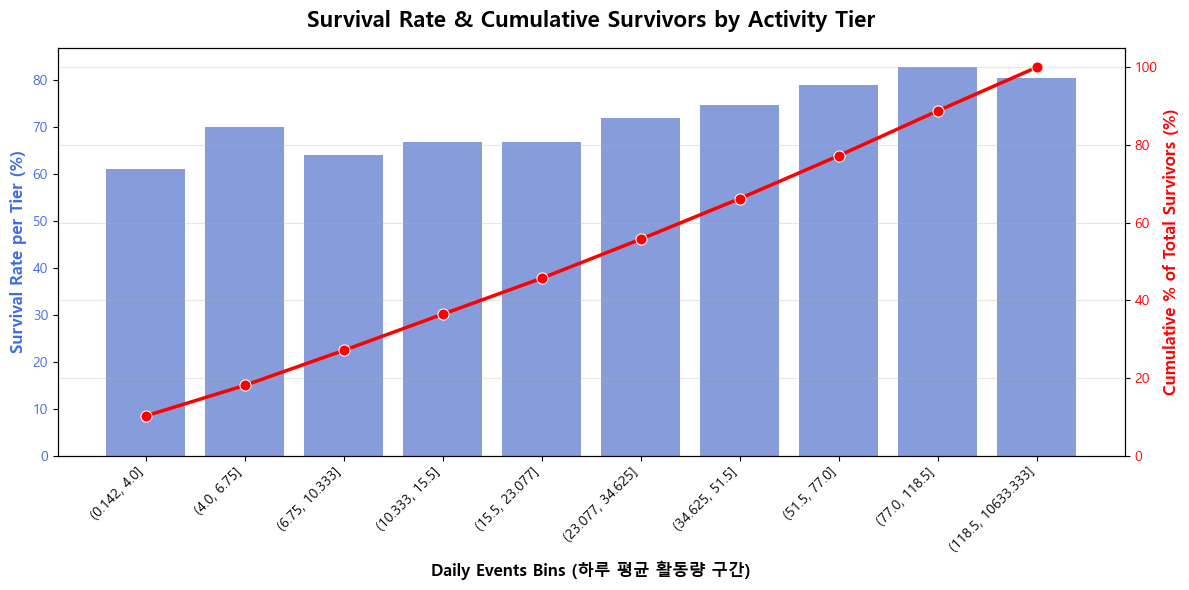

In [ ]:
df_2day['daily_events'] = df_2day['nevents'] / df_2day['ndays_act']
df_2day_over = df_viewed[df_viewed['duration'] >= 2]
df_2day_over['daily_events'] = df_2day_over['nevents'] / df_2day_over['ndays_act']

df_2day['is_survivor'] = 0
df_2day_over['is_survivor'] = 1

# 1. 성공 그룹과 초기 이탈 그룹 데이터 합치기
df_compare = pd.concat([df_2day_over, df_2day])

# 2. 하루 평균 클릭수(daily_events)를 10개의 등급으로 쪼개기
df_compare['activity_tier'] = pd.qcut(df_compare['daily_events'], q=10, duplicates='drop')

# 3. 단순 비율이 아닌, '진짜 유저 수'와 '생존자 수'를 집계합니다.
agg_df = df_compare.groupby('activity_tier')['is_survivor'].agg(['count', 'sum']).reset_index()
agg_df.rename(columns={'count': 'total_users', 'sum': 'survivors'}, inplace=True)

# 4. 누적합(cumsum) 계산 (사람 수를 먼저 누적시킵니다)
agg_df['cum_users'] = agg_df['total_users'].cumsum()
agg_df['cum_survivors'] = agg_df['survivors'].cumsum()

# 5. 그래프에 띄울 두 가지 핵심 지표 계산
# ① 각 티어별 독립 생존율 (파란 막대용)
agg_df['tier_survival_rate'] = (agg_df['survivors'] / agg_df['total_users']) * 100

# 6 누적 생존자 확보 비율 (빨간 꺾은선용 - "우리가 생존자를 얼마나 커버했나?")
agg_df['cum_survivor_pct'] = (agg_df['cum_survivors'] / agg_df['survivors'].sum()) * 100

# ==========================================
# 7. 이중 축(Twinx) 시각화 그리기
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# [왼쪽 Y축] 각 티어별 생존율 (막대 그래프)
sns.barplot(data=agg_df, x=agg_df['activity_tier'].astype(str), y='tier_survival_rate', 
            color='royalblue', alpha=0.7, ax=ax1)
ax1.set_ylabel('Survival Rate per Tier (%)', fontsize=12, color='royalblue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xlabel('Daily Events Bins (하루 평균 활동량 구간)', fontsize=12, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# [오른쪽 Y축] 생존자 누적 % (꺾은선 그래프)
ax2 = ax1.twinx()
sns.lineplot(data=agg_df, x=agg_df['activity_tier'].astype(str), y='cum_survivor_pct', 
             color='red', marker='o', markersize=8, linewidth=2.5, ax=ax2)
ax2.set_ylabel('Cumulative % of Total Survivors (%)', fontsize=12, color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105) # 누적 퍼센트니까 0~100까지 고정

plt.title('Survival Rate & Cumulative Survivors by Activity Tier', fontsize=16, fontweight='bold', pad=15)
plt.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

In [35]:
# 이거는 일단 예시
target_events = 52
real_events = df_2day['daily_events'].median()

print("초기 48시간 최소 활동 목표치")
print(f"이탈 방지를 위한 최소 하루 마지노선: 하루 클릭 {target_events:.1f}회")
print(f"2일 차 이탈자들의 실제 활동량 : 하루 클릭 {real_events:.1f}회")
print("-" * 50)
print(f"가입 직후 2일 동안, 유저의 클릭을 {target_events - real_events:.1f}회 더 유도")

초기 48시간 최소 활동 목표치
이탈 방지를 위한 최소 하루 마지노선: 하루 클릭 52.0회
2일 차 이탈자들의 실제 활동량 : 하루 클릭 16.0회
--------------------------------------------------
가입 직후 2일 동안, 유저의 클릭을 36.0회 더 유도


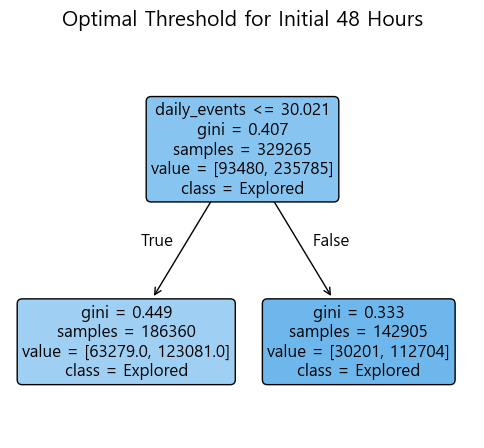

In [36]:
# 트리로도 해봤지만, 분리된 개수를 보았을 때 어느 정도의 합리성이 떨어져보이긴 함.
from sklearn.tree import DecisionTreeClassifier
import graphviz

# 2일 안에 이탈한 사람, explored까지 도달한 사람
df_compare = df_compare[df_compare['daily_events'].notna()]

X = df_compare[['daily_events']]
y = df_compare['is_survivor']

tree_model = DecisionTreeClassifier(max_depth = 1)
tree_model.fit(X,y)

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(6, 5)) # 그래프 크기 설정

# plot_tree 함수로 한 방에 그리기
plot_tree(
    tree_model,
    feature_names=['daily_events'],
    class_names=['Early Fail', 'Explored'],
    filled=True,
    rounded=True,
    fontsize=12 # 글자 크기
)

plt.title('Optimal Threshold for Initial 48 Hours', fontsize=15, pad=20)
plt.show()

이탈이 가장 많은 구간이 2일까지긴 하지만, 행동 지표가 충분히 쌓이지 않은 상태로 특정 구간의 cutoff를 제시하기는 어렵다.

따라서, 최소 기준 ndays_act = 1이라는 기준과 함께, 2일 이상의 사람들이 클릭을 어느 정도로 하였는지에 대한 단순 quantile로 제시하는 정도로 마무리를 해야한다.

트리의 경우에도 대략 초기 이탈 유저의 2/3가량을 분리해내는 특정 기준이 될 수 있지만, 명확한 근거로서 활용되기에는 어렵다.

-> 이 기준의 특정 cutoff를 정하는 것도 결국 임의의 판단 기준이 될 수 밖에 없기 때문에, 2일보다는 행동 패턴이 쌓이는 14일까지를 초기로 정하고, PR curve를 통해 임계값을 설정하려고 한다.

### 2. 초기 이탈을 14일로 정의하고, PR을 통해 cutoff 계산

주의 : 단순 등록이 아닌, 14일까지 어느 정도 탐색을 한 유저들도 초기 이탈 유저로 함께 보기로 했지만,

PR 계산시 Registered까지 함께 고려하게 될 경우, 임계값 계산 시 0의 비율이 높아져 활동 지표들을 과소 추정하게 될 우려가 있다.

따라서, Registered는 제외하고 Viewed의 데이터에서 14일 이전, 이후로 임계값을 계산하려고 한다.

In [44]:
df_viewed['over_14_days'] = (df_viewed['duration'] > 14).astype(int)
df_viewed['over_14_days'].value_counts()

over_14_days
1    192785
0    132576
Name: count, dtype: int64

In [45]:
# 분석 대상 변수
funnel_cols = ["viewed", "explored"]
behavior_cols = ["nchapters", "nplay_video", "nevents", "ndays_act", "nforum_posts"]
demo_cat_cols = ["age_group", "LoE_DI", "gender"]

# age는 연속형 demographic
demo_cont_cols = ["age"]

In [ ]:
# 높은 학위일 수록 15일 이상을 학습하는 경향이 존재.
df_viewed.groupby("LoE_DI")["over_14_days"].mean()

LoE_DI
Bachelor's             0.572279
Doctorate              0.593534
Less than Secondary    0.546490
Master's               0.613253
Secondary              0.554691
unknown                0.667970
Name: over_14_days, dtype: float64

In [ ]:
# other의 경우 모두 14일 이전 이탈
# 여성의 경우 더 오래 학습하는 경향이 있다고 해석하긴 위험하긴 하지만, 단순히 보면 그렇게 볼 수도 있음
df_viewed.groupby("gender")["over_14_days"].mean()

gender
f          0.600938
m          0.566641
o          0.000000
unknown    0.687433
Name: over_14_days, dtype: float64

In [58]:
# 14일은 그래도 어느 정도 학습 관련 행동들이 쌓인 것을 확인할 수 있음
df_viewed.groupby("over_14_days")[behavior_cols].mean()

,nchapters,nplay_video,nevents,ndays_act,nforum_posts
over_14_days,,,,,
0,2.188856,23.159462,90.240003,1.924661,0.009828
1,5.246839,165.326183,924.277174,11.246259,0.055725


In [ ]:
# 14일은 그래도 어느 정도 학습 관련 행동들이 쌓인 것을 확인할 수 있음
# forum의 중위수가 둘 다 0인 것을 고려했을 때, nforum_posts는 위험할 수 있음
df_viewed.groupby("over_14_days")[behavior_cols].median()

,nchapters,nplay_video,nevents,ndays_act,nforum_posts
over_14_days,,,,,
0,2.0,8.0,27.0,1.0,0.0
1,3.0,33.0,140.0,5.0,0.0


C:\temp\ipykernel_25584\2466241841.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not over_14_days", "over_14_days"])


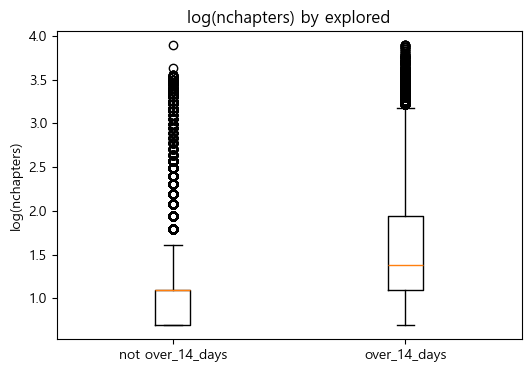

C:\temp\ipykernel_25584\2466241841.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not over_14_days", "over_14_days"])


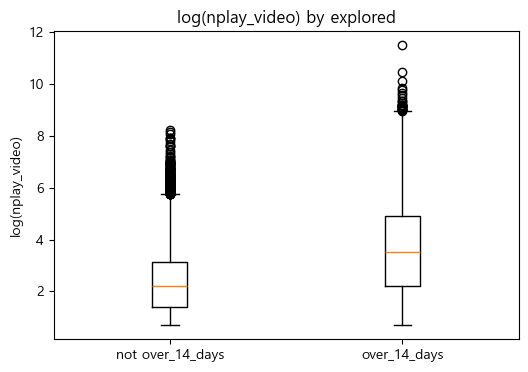

C:\temp\ipykernel_25584\2466241841.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not over_14_days", "over_14_days"])


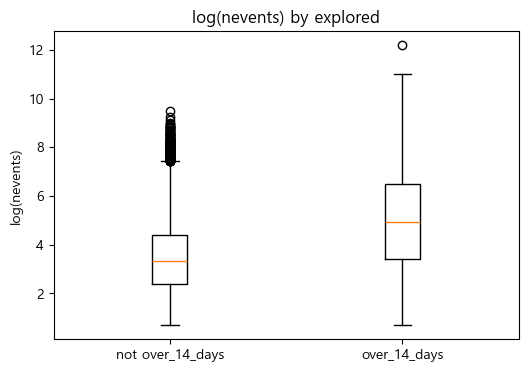

C:\temp\ipykernel_25584\2466241841.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not over_14_days", "over_14_days"])


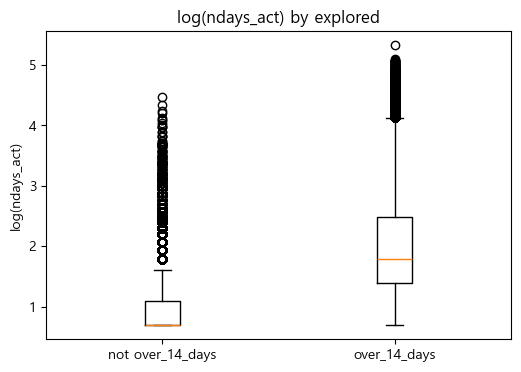

C:\temp\ipykernel_25584\2466241841.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["not over_14_days", "over_14_days"])


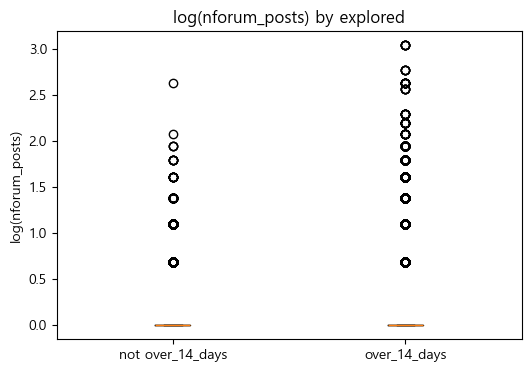

In [60]:
for col in behavior_cols:
    data0 = np.log1p(df_viewed[df_viewed["over_14_days"] == 0][col].dropna())
    data1 = np.log1p(df_viewed[df_viewed["over_14_days"] == 1][col].dropna())

    plt.figure(figsize=(6,4))
    plt.boxplot([data0, data1], labels=["not over_14_days", "over_14_days"])
    plt.title(f"log({col}) by explored")
    plt.ylabel(f"log({col})")
    plt.grid(False)
    plt.show()

In [61]:
# Cliff’s Delta 효과크기 함수
def cliffs_delta(x, y):
    nx = len(x)
    ny = len(y)

    greater = 0
    less = 0

    for xi in x:
        greater += np.sum(xi > y)
        less += np.sum(xi < y)

    delta = (greater - less) / (nx * ny)
    return delta

In [64]:
for col in behavior_cols:
    g0 = df_viewed[df_viewed["over_14_days"] == 0][col].dropna()
    g1 = df_viewed[df_viewed["over_14_days"] == 1][col].dropna()

    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    delta = cliffs_delta(g1, g0)

    print(f"{col}")
    print(f"p-value: {p:.4e}")
    print(f"{col}: Cliff's delta = {delta:.4f}")
    print(f"median (0): {g0.median():.4f}")
    print(f"median (1): {g1.median():.4f}")
    print("-"*40)

nchapters
p-value: 0.0000e+00
nchapters: Cliff's delta = 0.4236
median (0): 2.0000
median (1): 3.0000
----------------------------------------
nplay_video
p-value: 0.0000e+00
nplay_video: Cliff's delta = 0.4226
median (0): 8.0000
median (1): 33.0000
----------------------------------------
nevents
p-value: 0.0000e+00
nevents: Cliff's delta = 0.4500
median (0): 27.0000
median (1): 140.0000
----------------------------------------
ndays_act
p-value: 0.0000e+00
ndays_act: Cliff's delta = 0.7057
median (0): 1.0000
median (1): 5.0000
----------------------------------------
nforum_posts
p-value: 0.0000e+00
nforum_posts: Cliff's delta = 0.0261
median (0): 0.0000
median (1): 0.0000
----------------------------------------


### explored 단계 전환 요인 분석

Mann-Whitney U 검정 결과, explored 여부에 따라 주요 행동 변수들은 모두 통계적으로 유의한 차이를 보였다 (p < 0.001).

또한 효과크기(Cliff’s Delta)를 확인한 결과, nchapters(≈0.98), ndays_act(≈0.81), nplay_video(≈0.76), nevents(≈0.74) 등 대부분의 행동 변수에서 매우 큰 수준의 효과크기가 나타났다. 특히 nchapters의 경우 거의 완벽에 가까운 분리력을 보이며, explored 여부를 강하게 구분하는 변수로 확인되었다.

이는 explored 단계가 특정 단일 행동에 의해 발생한다기보다, 전반적인 학습 활동 수준이 일정 수준 이상 누적되었을 때 나타나는 결과적 지표임을 시사한다.

한편, nforum_posts의 경우 효과크기가 매우 낮고 중앙값 또한 차이가 없어, 포럼 활동은 explored 여부와 큰 관련이 없는 것으로 나타났다.

In [69]:
# nchapters 기본 분포 확인
print(df_viewed["ndays_act"].describe())

# over_14_days 중앙값도 다시 확인
print(
    df_viewed.groupby("over_14_days")["ndays_act"]
    .describe()[["count", "mean", "50%", "75%", "max"]]
)

count    323554.000000
mean          7.478801
std          13.642901
min           1.000000
25%           1.000000
50%           3.000000
75%           7.000000
max         205.000000
Name: ndays_act, dtype: float64
                 count       mean  50%   75%    max
over_14_days                                       
0             130769.0   1.924661  1.0   2.0   87.0
1             192785.0  11.246259  5.0  11.0  205.0


In [67]:
# over_14_days 분포 확인
class_counts = df_viewed["over_14_days"].value_counts(dropna=False)
class_ratio = df_viewed["over_14_days"].value_counts(normalize=True, dropna=False) * 100

print("[Class Count]")
print(class_counts)

print("\n[Class Ratio (%)]")
print(class_ratio)

[Class Count]
over_14_days
1    192785
0    132576
Name: count, dtype: int64

[Class Ratio (%)]
over_14_days
1    59.252646
0    40.747354
Name: proportion, dtype: float64


In [81]:
roc_df = df_viewed.copy()
roc_df["ndays_act"] = roc_df["ndays_act"]
roc_df = roc_df[roc_df['ndays_act'].notna()]

y = roc_df["over_14_days"]
x = roc_df["ndays_act"]

# ROC 기반 값
fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

# PR 기반 값
precision, recall, pr_thresholds = precision_recall_curve(y, x)

# precision_recall_curve는 thresholds 길이가 precision/recal보다 1 짧음
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

print(f"Best ROC threshold (Youden J): {best_threshold_roc}")
print(f"Best PR threshold (F1): {best_threshold_pr}")

Best ROC threshold (Youden J): 3.0
Best PR threshold (F1): 2.0


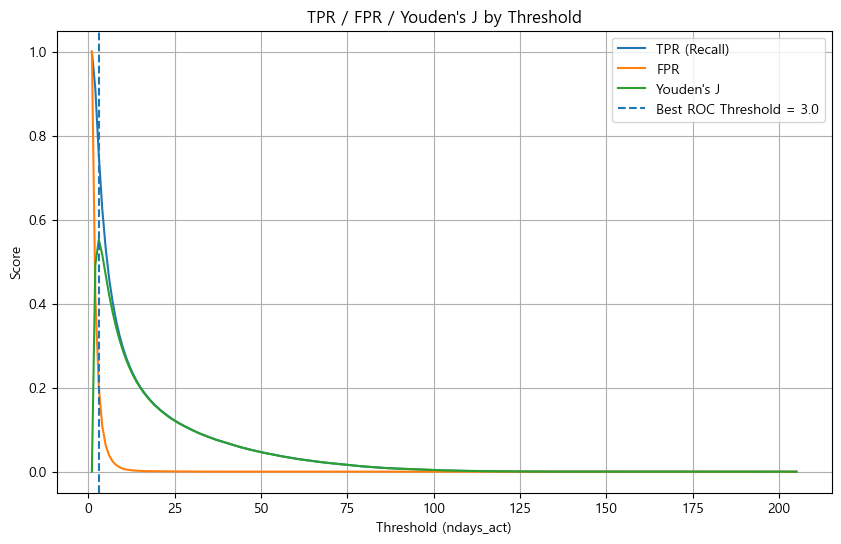

In [82]:
# ROC 기준으로 threshold가 바뀔 때
plt.figure(figsize=(10, 6))
plt.plot(roc_thresholds, tpr, label="TPR (Recall)")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")

plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")

plt.xlabel("Threshold (ndays_act)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
roc_df = df_viewed.copy()
roc_df["nevents"] = roc_df["nevents"]
roc_df = roc_df[roc_df['nevents'].notna()]

y = roc_df["over_14_days"]
x = roc_df["nevents"]

# ROC 기반 값
fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

# PR 기반 값
precision, recall, pr_thresholds = precision_recall_curve(y, x)

# precision_recall_curve는 thresholds 길이가 precision/recal보다 1 짧음
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

print(f"Best ROC threshold (Youden J): {best_threshold_roc}")
print(f"Best PR threshold (F1): {best_threshold_pr}")

Best ROC threshold (Youden J): 105.0
Best PR threshold (F1): 1.0


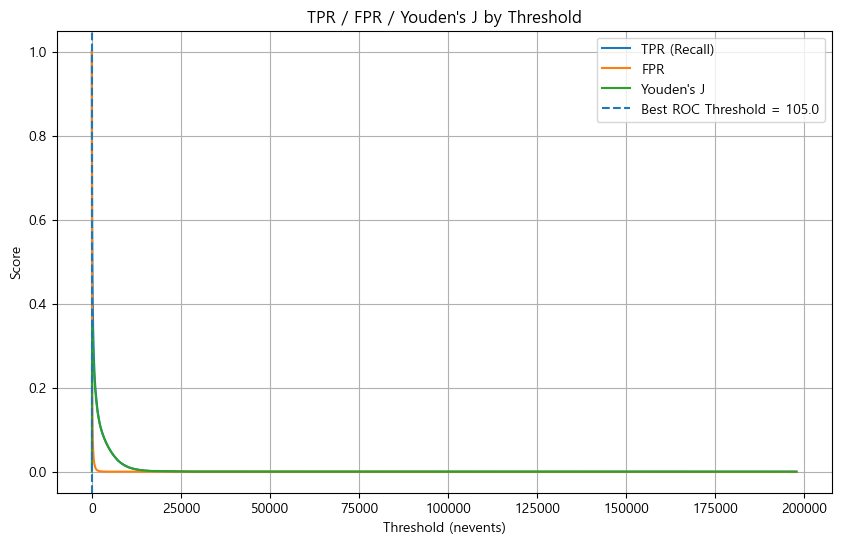

In [84]:
# ROC 기준으로 threshold가 바뀔 때
plt.figure(figsize=(10, 6))
plt.plot(roc_thresholds, tpr, label="TPR (Recall)")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")

plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")

plt.xlabel("Threshold (nevents)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [85]:
roc_df = df_viewed.copy()
roc_df["nplay_video"] = roc_df["nplay_video"]
roc_df = roc_df[roc_df['nplay_video'].notna()]

y = roc_df["over_14_days"]
x = roc_df["nplay_video"]

# ROC 기반 값
fpr, tpr, roc_thresholds = roc_curve(y, x)
j_scores = tpr - fpr
best_idx_roc = np.argmax(j_scores)
best_threshold_roc = roc_thresholds[best_idx_roc]

# PR 기반 값
precision, recall, pr_thresholds = precision_recall_curve(y, x)

# precision_recall_curve는 thresholds 길이가 precision/recal보다 1 짧음
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx_pr = np.argmax(f1_scores)
best_threshold_pr = pr_thresholds[best_idx_pr]

print(f"Best ROC threshold (Youden J): {best_threshold_roc}")
print(f"Best PR threshold (F1): {best_threshold_pr}")

Best ROC threshold (Youden J): 28.0
Best PR threshold (F1): 1.0


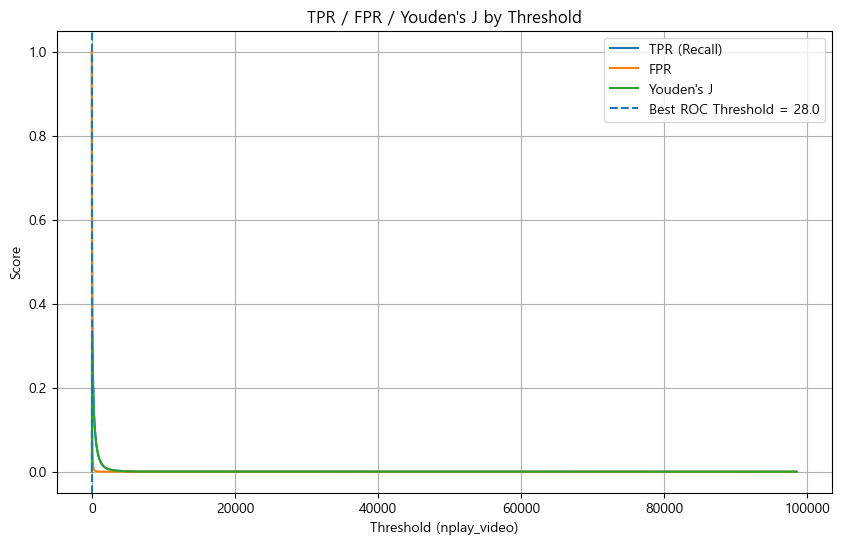

In [86]:
# ROC 기준으로 threshold가 바뀔 때
plt.figure(figsize=(10, 6))
plt.plot(roc_thresholds, tpr, label="TPR (Recall)")
plt.plot(roc_thresholds, fpr, label="FPR")
plt.plot(roc_thresholds, j_scores, label="Youden's J")

plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.1f}")

plt.xlabel("Threshold (nplay_video)")
plt.ylabel("Score")
plt.title("TPR / FPR / Youden's J by Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
def cap_upper(series, q=0.99):
    upper = series.quantile(q)
    return series.clip(upper=upper)

def threshold_summary(y, x):
    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y, x)
    j_scores = tpr - fpr
    best_idx_roc = np.argmax(j_scores)
    best_threshold_roc = roc_thresholds[best_idx_roc]

    # PR
    precision, recall, pr_thresholds = precision_recall_curve(y, x)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx_pr = np.argmax(f1_scores)
    best_threshold_pr = pr_thresholds[best_idx_pr]

    return {
        "roc_threshold": best_threshold_roc,
        "roc_j": j_scores[best_idx_roc],
        "pr_threshold": best_threshold_pr,
        "precision": precision[best_idx_pr],
        "recall": recall[best_idx_pr],
        "f1": f1_scores[best_idx_pr]
    }

def compare_versions(df, target_col, feature_col, cap_q=0.99):
    temp = df[[target_col, feature_col]].dropna().copy()
    temp["raw"] = temp[feature_col]
    temp["log1p"] = np.log1p(temp[feature_col])
    temp["capped"] = cap_upper(temp[feature_col], q=cap_q)

    y = temp[target_col].astype(int)

    rows = []
    for version in ["raw", "log1p", "capped"]:
        result = threshold_summary(y, temp[version])

        if version == "log1p":
            roc_thr = np.expm1(result["roc_threshold"])
            pr_thr = np.expm1(result["pr_threshold"])
        else:
            roc_thr = result["roc_threshold"]
            pr_thr = result["pr_threshold"]

        rows.append({
            "version": version,
            "roc_threshold": roc_thr,
            "roc_j": result["roc_j"],
            "pr_threshold": pr_thr,
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"]
        })

    return temp, pd.DataFrame(rows)

def plot_distributions(temp, original_col, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(temp["raw"], bins=50)
    axes[0].set_title(f"{title_prefix} Raw")

    axes[1].hist(temp["log1p"], bins=50)
    axes[1].set_title(f"{title_prefix} log1p")

    axes[2].hist(temp["capped"], bins=50)
    axes[2].set_title(f"{title_prefix} capped")

    for ax in axes:
        ax.set_ylabel("Frequency")
        ax.grid(False)

    plt.tight_layout()
    plt.show()

def plot_threshold_curves(temp, target_col, feature_version, title_prefix=""):
    y = temp[target_col].astype(int).values
    x = temp[feature_version].values

    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y, x)
    j_scores = tpr - fpr
    best_idx_roc = np.argmax(j_scores)
    best_threshold_roc = roc_thresholds[best_idx_roc]

    # PR
    precision, recall, pr_thresholds = precision_recall_curve(y, x)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    best_idx_pr = np.argmax(f1_scores)
    best_threshold_pr = pr_thresholds[best_idx_pr]

    plt.figure(figsize=(8, 5))
    plt.plot(pr_thresholds, precision[:-1], label="Precision")
    plt.plot(pr_thresholds, recall[:-1], label="Recall")
    plt.plot(pr_thresholds, f1_scores, label="F1 Score")
    plt.axvline(best_threshold_pr, linestyle="--", label=f"Best PR Threshold = {best_threshold_pr:.3f}")
    plt.xlabel(f"Threshold ({feature_version})")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} PR-based Threshold Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(roc_thresholds, tpr, label="TPR")
    plt.plot(roc_thresholds, fpr, label="FPR")
    plt.plot(roc_thresholds, j_scores, label="Youden's J")
    plt.axvline(best_threshold_roc, linestyle="--", label=f"Best ROC Threshold = {best_threshold_roc:.3f}")
    plt.xlabel(f"Threshold ({feature_version})")
    plt.ylabel("Score")
    plt.title(f"{title_prefix} ROC-based Threshold Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

count    181259.000000
mean        116.100900
std         429.516353
min           1.000000
50%          18.000000
75%          74.000000
90%         276.000000
95%         553.000000
99%        1529.000000
max       98517.000000
Name: nplay_video, dtype: float64


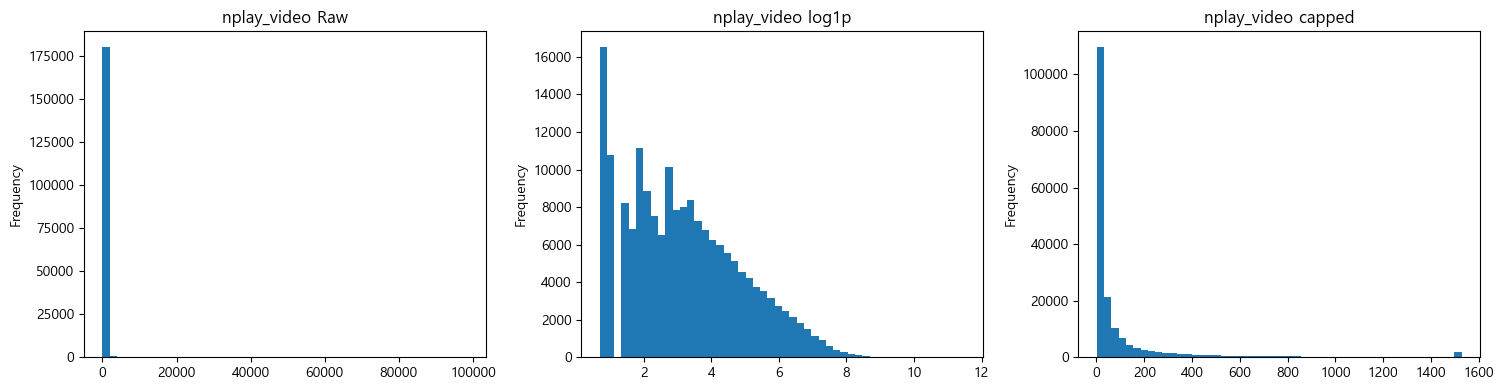

,version,roc_threshold,roc_j,pr_threshold,precision,recall,f1
0,raw,28.0,0.328035,1.0,0.65375,1.0,0.790627
1,log1p,28.0,0.328035,1.0,0.65375,1.0,0.790627
2,capped,28.0,0.328035,1.0,0.65375,1.0,0.790627


In [91]:
print(df_viewed["nplay_video"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

temp_video, result_video = compare_versions(
    df=df_viewed,
    target_col="over_14_days",
    feature_col="nplay_video",
    cap_q=0.99
)

plot_distributions(temp_video, "nplay_video", title_prefix="nplay_video")
display(result_video)